# データサイエンス特論 第6回 演習課題
青山学院大学大学院 理工学研究科 理工学専攻 知能情報コース 修士1年 35626302 森下剛

In [120]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

描画関数を以下に定義する。

In [121]:
def f_plot_fill_rejection(dfn, dfd, xmax, p, stat=None):
    X = np.arange(0.001, xmax, 0.01)
    Y = stats.f.pdf(X, dfn=dfn, dfd=dfd)

    fig, ax = plt.subplots()
    ax.plot(X, Y, color='blue')

    alpha = 1 - p
    x_lower = stats.f.ppf(alpha / 2, dfn=dfn, dfd=dfd)
    x_upper = stats.f.ppf(1 - alpha / 2, dfn=dfn, dfd=dfd)

    X_lower = np.arange(0.001, x_lower, 0.001)
    ax.fill_between(X_lower, stats.f.pdf(X_lower, dfn=dfn, dfd=dfd), color='red', alpha=0.5)
    X_upper = np.arange(x_upper, xmax, 0.001)
    ax.fill_between(X_upper, stats.f.pdf(X_upper, dfn=dfn, dfd=dfd), color='red', alpha=0.5)

    if stat is not None:
        ax.axvline(stat, color='green', linestyle='-', label=f'F = {stat:.3f}')
        ax.legend()

    ax.set_xlabel('X')
    ax.set_ylabel('Probability density')
    ax.set_title(f'rejection region (significance level {int(alpha*100)}%): x < {x_lower:.3f}, x > {x_upper:.3f}')
    plt.show()

In [122]:
def t_plot_fill_rejection(df, xrange, p, stat=None):
    X = np.arange(-xrange, xrange, 0.01)
    Y = stats.t.pdf(X, df=df)

    fig, ax = plt.subplots()
    ax.plot(X, Y, color='blue')

    alpha = 1 - p
    x_lower = stats.t.ppf(alpha / 2, df=df)
    x_upper = stats.t.ppf(1 - alpha / 2, df=df)

    X_lower = np.arange(-xrange, x_lower, 0.001)
    ax.fill_between(X_lower, stats.t.pdf(X_lower, df=df), color='red', alpha=0.5)
    X_upper = np.arange(x_upper, xrange, 0.001)
    ax.fill_between(X_upper, stats.t.pdf(X_upper, df=df), color='red', alpha=0.5)

    if stat is not None:
        ax.axvline(stat, color='green', linestyle='-', label=f'T = {stat:.3f}')
        ax.legend()

    ax.set_xlabel('X')
    ax.set_ylabel('Probability density')
    ax.set_title(f'rejection region (significance level {int(alpha*100)}%): x < {x_lower:.3f}, x > {x_upper:.3f}')
    plt.show()


#### 演習問題1-1の回答

分散が等しいことを判定するにはF検定を用いる。

In [123]:
n_A = 10
n_B = 10
S2_A = 3.2 ** 2
S2_B = 1.5 ** 2

df_A = n_A - 1
df_B = n_B - 1

F = S2_A / S2_B
print(f"F = {F}")

alpha = 0.01
f_lower = stats.f.ppf(alpha / 2, dfn=df_A, dfd=df_B)
f_upper = stats.f.ppf(1 - alpha / 2, dfn=df_A, dfd=df_B)
print(f"下側0.5％点: {f_lower:.4f}")
print(f"上側0.5％点: {f_upper:.4f}")

F = 4.551111111111112
下側0.5％点: 0.1529
上側0.5％点: 6.5411


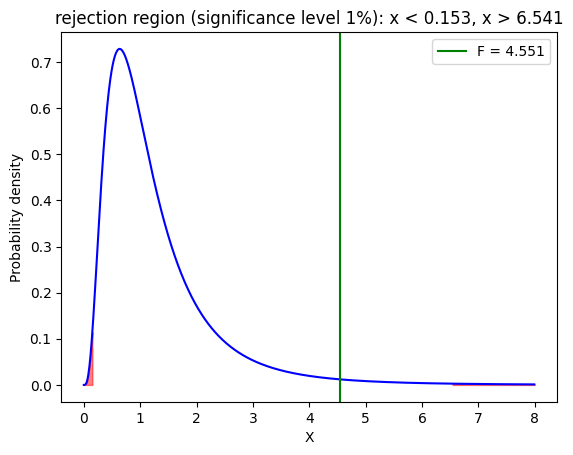

In [124]:
f_plot_fill_rejection(dfn=df_A, dfd=df_B, xmax=8, p=1 - alpha, stat=F)


有意水準1％でAとBの母分散が等しいと言える。

#### 演習問題1-2の回答

1-1よりAとBの母分散が等しいとみなせるのでステューデントのt検定を用いる。

In [125]:
mean_A = 90
mean_B = 87

df_st = n_A + n_B - 2

T = (mean_A - mean_B) / np.sqrt((1 / n_A + 1 / n_B) * ((n_A - 1) * S2_A + (n_B - 1) * S2_B) / df_st)
print(f"T = {T}")

t_lower = stats.t.ppf(alpha / 2, df=df_st)
t_upper = stats.t.ppf(1 - alpha / 2, df=df_st)
print(f"下側0.5％点: {t_lower:.4f}")
print(f"上側0.5％点: {t_upper:.4f}")


T = 2.6843555300461506
下側0.5％点: -2.8784
上側0.5％点: 2.8784


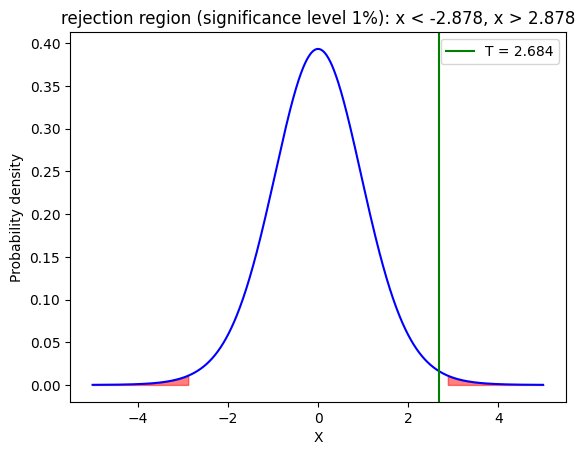

In [126]:
t_plot_fill_rejection(df=df_st, xrange=5, p=1 - alpha, stat=T)


有意水準1％ではAとBの母平均に優位な差はないと言える。

#### 演習問題2の回答

In [127]:
def F_test(n, sigma2_A, sigma2_B, a, make_fig=False):
    df_A = n - 1
    df_B = n - 1
    F = sigma2_A / sigma2_B
    alpha = a / 100

    f_lower = stats.f.ppf(alpha / 2, dfn=df_A, dfd=df_B)
    f_upper = stats.f.ppf(1 - alpha / 2, dfn=df_A, dfd=df_B)

    if make_fig:
        xmax = max(F * 1.5, f_upper * 1.5)
        f_plot_fill_rejection(dfn=df_A, dfd=df_B, xmax=xmax, p=1 - alpha, stat=F)

    return F < f_lower or F > f_upper


In [128]:
def student_t(n, mu_A, mu_B, sigma2_A, sigma2_B, a, make_fig=False):
    df = 2 * n - 2
    T = (mu_A - mu_B) / np.sqrt((1 / n + 1 / n) * ((n - 1) * sigma2_A + (n - 1) * sigma2_B) / df)
    alpha = a / 100

    t_lower = stats.t.ppf(alpha / 2, df=df)
    t_upper = stats.t.ppf(1 - alpha / 2, df=df)

    if make_fig:
        t_plot_fill_rejection(df=df, xrange=5, p=1 - alpha, stat=T)

    return T < t_lower or T > t_upper


In [129]:
def welch_t(n, mu_A, mu_B, sigma2_A, sigma2_B, a, make_fig=False):
    T = (mu_A - mu_B) / np.sqrt(sigma2_A / n + sigma2_B / n)
    nu = (sigma2_A / n + sigma2_B / n) ** 2 / ((sigma2_A / n) ** 2 / (n - 1) + (sigma2_B / n) ** 2 / (n - 1))
    alpha = a / 100

    t_lower = stats.t.ppf(alpha / 2, df=nu)
    t_upper = stats.t.ppf(1 - alpha / 2, df=nu)

    if make_fig:
        t_plot_fill_rejection(df=nu, xrange=5, p=1 - alpha, stat=T)

    return T < t_lower or T > t_upper


In [130]:
def pmean_test(n, mu_A, mu_B, sigma2_A, sigma2_B, a, make_fig=False):
    is_unequal_var = F_test(n, sigma2_A, sigma2_B, a, make_fig=make_fig)

    if is_unequal_var:
        return welch_t(n, mu_A, mu_B, sigma2_A, sigma2_B, a, make_fig=make_fig)
    else:
        return student_t(n, mu_A, mu_B, sigma2_A, sigma2_B, a, make_fig=make_fig)


動作確認を行う。

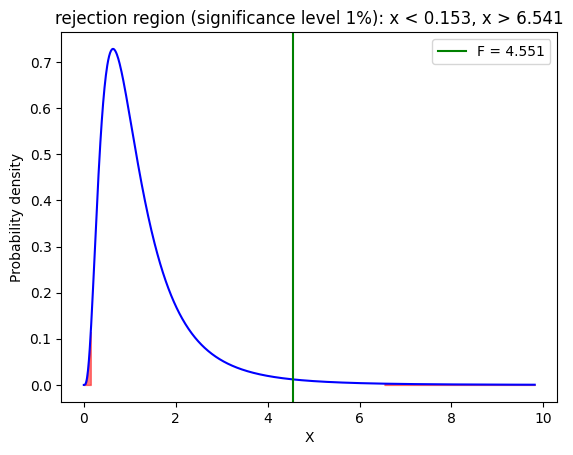

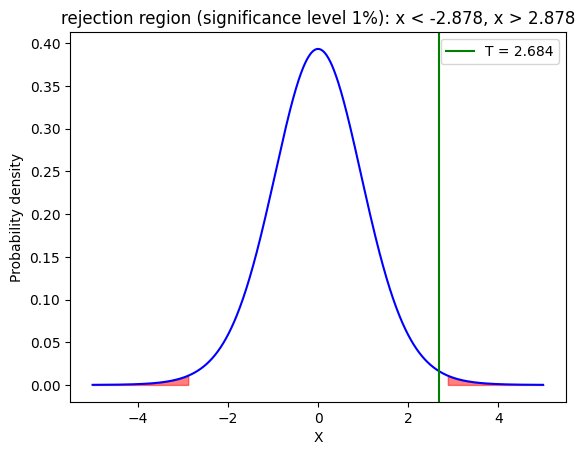

np.False_

In [131]:
pmean_test(n=10, mu_A=90, mu_B=87, sigma2_A=3.2**2, sigma2_B=1.5**2, a=1, make_fig=True)

演習問題1と同じ引数でFalseが帰った。これはAとBの母平均に優位な差はないことを意味しており、演習問題1-2の答えと一致する。